# FraudShield-AI

## Model Development

### Objective

The purpose of this notebook is to prepare the data for machine learning and develop the first deep learning model capable of detecting fraudulent credit card transactions.

This notebook will:

- Prepare the dataset for training
- Split the data into training and testing sets
- Scale numerical features
- Build a Dense Neural Network using TensorFlow/Keras
- Train the model
- Evaluate its performance

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
)

# TensorFlow
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# Load the Dataset

## Objective

Load the dataset and prepare it for preprocessing before training the neural network.

In [3]:
df = pd.read_csv("../data/raw/creditcard.csv")

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


# Remove Duplicate Transactions

## Objective

Duplicate transactions can introduce bias into the training process.

Removing duplicate records helps the neural network learn general fraud patterns rather than memorizing repeated observations.

In [4]:
print(f"Original Shape: {df.shape}")

df = df.drop_duplicates()

print(f"New Shape: {df.shape}")

Original Shape: (284807, 31)
New Shape: (283726, 31)


## Interpretation

The dataset originally contained **284,807** transactions. After removing duplicate records, **283,726** unique transactions remained.

Removing duplicate observations helps reduce bias during training and encourages the neural network to learn meaningful fraud patterns rather than memorizing repeated transactions.

# Separate Features and Target

## Objective

Machine learning models require the input features and target variable to be separated.

The features (`X`) contain the information used to make predictions, while the target (`y`) contains the correct labels that the model will learn to predict.

In [5]:
# Separate features and target
X = df.drop("Class", axis=1)

y = df["Class"]

In [6]:
print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (283726, 30)
Target Shape: (283726,)


## Interpretation

The dataset has been successfully separated into input features (`X`) and the target variable (`y`).

The neural network will use the 30 numerical features to learn patterns associated with fraudulent transactions and predict the value of the target variable (`Class`).

# Train-Test Split

## Objective

The dataset is divided into training and testing sets to evaluate the model's ability to generalize to unseen transaction data.

The training dataset will be used to teach the neural network patterns associated with legitimate and fraudulent transactions. The testing dataset will remain separate and will be used to evaluate the final model.

Because fraudulent transactions represent a very small percentage of the dataset, stratified sampling is used to preserve the class distribution in both datasets.

In [7]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [8]:
# Display training and testing dataset shapes
print("X_train Shape:", X_train.shape)
print("X_test Shape:", X_test.shape)
print("y_train Shape:", y_train.shape)
print("y_test Shape:", y_test.shape)

X_train Shape: (226980, 30)
X_test Shape: (56746, 30)
y_train Shape: (226980,)
y_test Shape: (56746,)


In [9]:
# Verify class distribution after the split
print("Training Class Distribution:")
print((y_train.value_counts(normalize=True) * 100).round(2))

print("\nTesting Class Distribution:")
print((y_test.value_counts(normalize=True) * 100).round(2))

Training Class Distribution:
Class
0    99.83
1     0.17
Name: proportion, dtype: float64

Testing Class Distribution:
Class
0    99.83
1     0.17
Name: proportion, dtype: float64


## Interpretation

The dataset was divided into 80% training data and 20% testing data.

Stratified sampling was used to preserve the severe class imbalance observed in the original dataset. Both the training and testing datasets maintain approximately the same proportion of legitimate and fraudulent transactions.

Maintaining the class distribution helps ensure that the final evaluation reflects the characteristics of the original transaction dataset.

# Feature Scaling

## Objective

Neural networks generally perform better when numerical input features are on comparable scales.

Although the anonymized PCA features are already centered around zero, the `Time` and `Amount` features operate on different numerical ranges.

Standardization is applied to the input features using `StandardScaler`. The scaler is fitted only on the training data to prevent information from the testing dataset from influencing the training process.

In [10]:
# Create the feature scaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform it
X_train_scaled = scaler.fit_transform(X_train)

# Transform the testing data using the training scaler
X_test_scaled = scaler.transform(X_test)

In [11]:
# Verify the scaled training data
print("Original Training Data:")
print(X_train.iloc[:5, [0, 29]])

print("\nScaled Training Data:")
print(X_train_scaled[:5, [0, 29]])

Original Training Data:
            Time  Amount
226238  144549.0   32.00
134253   80716.0    6.99
186465  127116.0   14.95
149493   91342.0   17.30
18461    29522.0   24.00

Scaled Training Data:
[[ 1.04549909 -0.22943372]
 [-0.29869002 -0.33119698]
 [ 0.67839667 -0.29880852]
 [-0.07492874 -0.28924659]
 [-1.3767283  -0.26198495]]


## Interpretation

The training and testing features were standardized using `StandardScaler`.

The scaler was fitted exclusively on the training dataset and then applied to the testing dataset. This prevents data leakage and ensures that the final model is evaluated using data that did not influence the preprocessing calculations.

Feature scaling places the numerical inputs on comparable scales, which can improve the stability and efficiency of neural network training.

# Baseline Neural Network

## Objective

The first model developed for FraudShield-AI will serve as a baseline for evaluating future improvements.

A Dense Neural Network, also known as a Multilayer Perceptron (MLP), is used because the credit card transaction dataset consists of structured numerical features.

The baseline model intentionally uses a simple architecture without class weighting or dropout regularization. Its performance will be evaluated before additional techniques are introduced.

In [12]:
# Build the baseline neural network
baseline_model = Sequential([
    keras.Input(shape=(X_train_scaled.shape[1],)),
    Dense(64, activation="relu"),
    Dense(32, activation="relu"),
    Dense(1, activation="sigmoid")
])

# Display the model architecture
baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,097 (16.00 KB)

 Trainable params: 4,097 (16.00 KB)

 Non-trainable params: 0 (0.00 B)

## Architecture Explanation

The baseline model uses a feedforward Dense Neural Network designed for binary classification.

The network receives 30 numerical transaction features as input. Two hidden Dense layers containing 64 and 32 neurons use the ReLU activation function to learn nonlinear relationships within the transaction data.

The output layer contains a single neuron with a sigmoid activation function. This produces a value between 0 and 1 representing the model's predicted probability that a transaction is fraudulent.

This simple architecture establishes a baseline that can later be compared against an improved model.

# Compile the Baseline Model

## Objective

Before training, the neural network must be configured with a loss function, optimizer, and evaluation metrics.

Because this is a binary classification problem, binary cross-entropy is used as the loss function. The Adam optimizer is used to update the model weights during training.

In addition to accuracy, precision and recall are included because the dataset is highly imbalanced.

In [13]:
# Compile the baseline model
baseline_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        keras.metrics.Precision(name="precision"),
        keras.metrics.Recall(name="recall")
    ]
)

## Compilation Explanation

The baseline model uses binary cross-entropy because the target contains two possible classes.

The Adam optimizer is used to update model weights during training. Accuracy, precision, and recall are tracked so that performance can be evaluated beyond overall accuracy.

Precision helps measure the number of false fraud alerts, while recall measures how many actual fraudulent transactions are successfully detected.

# Train the Baseline Model

## Objective

The baseline neural network will be trained using the scaled training data.

A validation split is used to evaluate the model on data that is not used to update the network weights during each epoch.

In [14]:
# Train the baseline model
baseline_history = baseline_model.fit(
    X_train_scaled,
    y_train,
    epochs=10,
    batch_size=256,
    validation_split=0.20,
    verbose=1
)

Epoch 1/10
710/710 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9985 - loss: 0.0226 - precision: 0.5641 - recall: 0.5133 - val_accuracy: 0.9995 - val_loss: 0.0028 - val_precision: 0.8904 - val_recall: 0.8333
Epoch 2/10
710/710 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9994 - loss: 0.0034 - precision: 0.8571 - recall: 0.7400 - val_accuracy: 0.9995 - val_loss: 0.0026 - val_precision: 0.8784 - val_recall: 0.8333
Epoch 3/10
710/710 ━━━━━━━━━━━━━━━━━━━━ 1s 951us/step - accuracy: 0.9994 - loss: 0.0029 - precision: 0.8577 - recall: 0.7633 - val_accuracy: 0.9995 - val_loss: 0.0025 - val_precision: 0.8500 - val_recall: 0.8718
Epoch 4/10
710/710 ━━━━━━━━━━━━━━━━━━━━ 1s 932us/step - accuracy: 0.9994 - loss: 0.0026 - precision: 0.8712 - recall: 0.7667 - val_accuracy: 0.9995 - val_loss: 0.0024 - val_precision: 0.8889 - val_recall: 0.8205
Epoch 5/10
710/710 ━━━━━━━━━━━━━━━━━━━━ 1s 952us/step - accuracy: 0.9995 - loss: 0.0024 - precision: 0.8915 - recall: 0.7667 - val_accuracy: 0.9996 - val_lo

## Baseline Training Interpretation

The baseline neural network demonstrated strong overall training and validation performance.

By the final epoch, the model achieved approximately 99.96% validation accuracy, 92.96% validation precision, and 84.62% validation recall.

Although the overall accuracy is high, accuracy must be interpreted carefully because the dataset is severely imbalanced. The recall score is particularly important for this fraud detection problem because it measures the model's ability to identify actual fraudulent transactions.

The validation recall indicates that the baseline model successfully detected a large proportion of fraudulent transactions. However, some fraudulent transactions were still missed.

This creates an opportunity to improve the model by increasing fraud recall while monitoring the effect on precision and false positive predictions.

In [15]:
# Display the metrics recorded during training
baseline_history.history.keys()

dict_keys(['accuracy', 'loss', 'precision', 'recall', 'val_accuracy', 'val_loss', 'val_precision', 'val_recall'])

# Training Curves

## Objective

Training curves help visualize how the neural network's performance changes across epochs.

Comparing training and validation metrics can help identify whether the model is learning effectively and whether signs of overfitting are present.

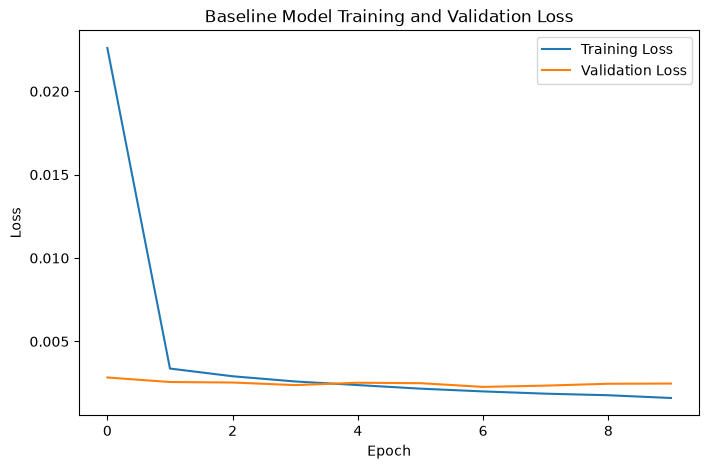

In [16]:
# Plot training and validation loss
plt.figure(figsize=(8, 5))

plt.plot(
    baseline_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    baseline_history.history["val_loss"],
    label="Validation Loss"
)

plt.title("Baseline Model Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

# Save the figure
plt.savefig(
    "../images/baseline_loss_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

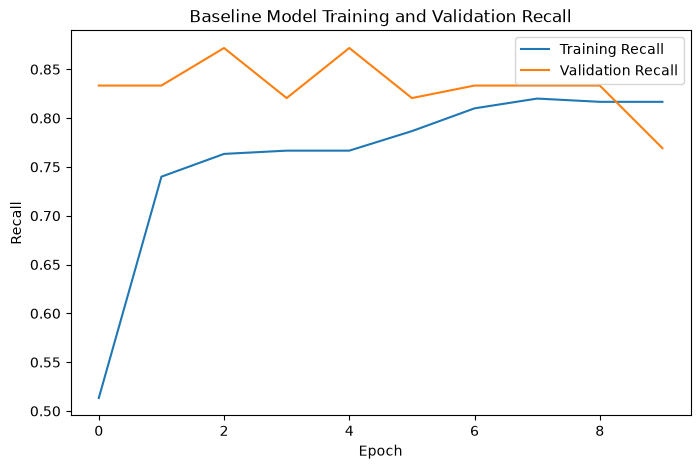

In [17]:
# Plot training and validation recall
plt.figure(figsize=(8, 5))

plt.plot(
    baseline_history.history["recall"],
    label="Training Recall"
)

plt.plot(
    baseline_history.history["val_recall"],
    label="Validation Recall"
)

plt.title("Baseline Model Training and Validation Recall")
plt.xlabel("Epoch")
plt.ylabel("Recall")
plt.legend()

# Save the figure
plt.savefig(
    "../images/baseline_recall_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Training Curve Interpretation

The baseline model learned rapidly during the initial training epochs, as demonstrated by the significant decrease in training loss.

Training loss continued to decrease throughout the 10 epochs, while validation loss remained low and relatively stable. The validation loss did not show a significant upward trend, suggesting that severe overfitting was not observed during baseline training.

The recall curves show that the model's ability to identify fraudulent transactions improved during training. Validation recall fluctuated across epochs but remained relatively strong, highlighting the challenge of evaluating a highly imbalanced dataset with a limited number of fraudulent validation examples.

The baseline model provides a strong starting point for further evaluation and improvement.

# Baseline Model Evaluation

## Objective

The baseline neural network is evaluated using the held-out testing dataset.

The testing dataset was not used to train the model and provides a more realistic assessment of how the model may perform on unseen transaction data.

Because credit card fraud detection is a highly imbalanced classification problem, the evaluation focuses on accuracy, precision, recall, F1-score, and the confusion matrix.

In [19]:
# Evaluate the baseline model on the test dataset
test_loss, test_accuracy, test_precision, test_recall = baseline_model.evaluate(
    X_test_scaled,
    y_test,
    verbose=1
)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Precision: {test_precision:.4f}")
print(f"Test Recall: {test_recall:.4f}")

1774/1774 ━━━━━━━━━━━━━━━━━━━━ 1s 569us/step - accuracy: 0.9993 - loss: 0.0046 - precision: 0.9833 - recall: 0.6211
Test Loss: 0.0046
Test Accuracy: 0.9993
Test Precision: 0.9833
Test Recall: 0.6211


In [20]:
# Generate fraud probability predictions
y_pred_prob = baseline_model.predict(X_test_scaled)

# Convert probabilities into binary class predictions
y_pred = (y_pred_prob >= 0.50).astype(int).ravel()

1774/1774 ━━━━━━━━━━━━━━━━━━━━ 1s 312us/step


In [22]:
# Display the classification report
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Legitimate", "Fraud"]
    )
)

              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56651
       Fraud       0.98      0.62      0.76        95

    accuracy                           1.00     56746
   macro avg       0.99      0.81      0.88     56746
weighted avg       1.00      1.00      1.00     56746



# Confusion Matrix

## Objective

The confusion matrix provides a detailed view of the model's predictions by comparing predicted transaction classes with the actual transaction classes.

This analysis helps identify correctly classified transactions, false fraud alerts, and fraudulent transactions missed by the model.

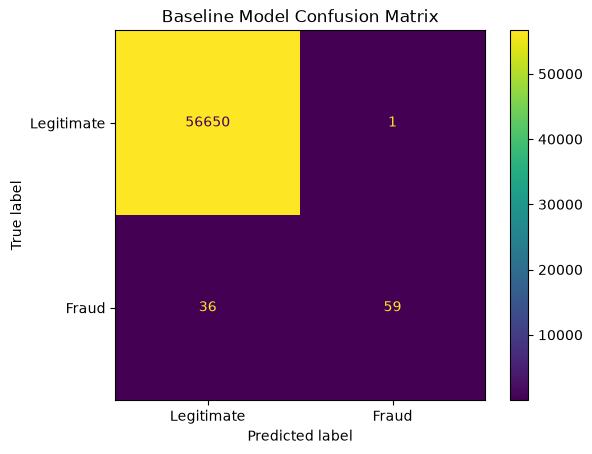

In [23]:
# Create the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display the confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Legitimate", "Fraud"]
)

disp.plot()

plt.title("Baseline Model Confusion Matrix")

# Save the figure
plt.savefig(
    "../images/baseline_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Baseline Evaluation Interpretation

The baseline neural network achieved excellent overall accuracy and precision when evaluated on the testing dataset.

The confusion matrix shows that only two legitimate transactions were incorrectly classified as fraudulent, demonstrating a very low false positive rate.

However, the model failed to detect 31 fraudulent transactions. These false negatives represent fraudulent activity that would not have been identified by the system.

Because fraud detection prioritizes identifying fraudulent transactions, improving recall will be the primary objective during the model improvement phase.

Future improvements will focus on reducing false negatives while maintaining strong precision.

# Model Improvement: Class Weighting

## Objective

The baseline neural network demonstrated high precision but failed to detect 31 fraudulent transactions in the testing dataset.

Because fraudulent transactions represent approximately 0.17% of the dataset, the baseline model receives significantly more examples of legitimate transactions during training.

The improved model will use class weighting to assign greater importance to fraudulent transactions during the training process.

The primary goal of this improvement is to increase fraud recall and reduce false negatives while monitoring the impact on precision.

In [24]:
# Calculate balanced class weights
class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

# Convert the class weights into a dictionary
class_weights = {
    0: class_weights_array[0],
    1: class_weights_array[1]
}

print("Class Weights:")
print(class_weights)

Class Weights:
{0: np.float64(0.5008340614822464), 1: np.float64(300.23809523809524)}


## Class Weight Interpretation

The calculated class weights reflect the severe imbalance between legitimate and fraudulent transactions.

Because legitimate transactions represent the overwhelming majority of the training dataset, they receive a smaller training weight. Fraudulent transactions receive a significantly larger weight because they represent the minority class.

During model training, these weights increase the penalty associated with incorrectly classifying fraudulent transactions. The goal is to encourage the neural network to identify more fraud cases and improve recall.

# Improved Neural Network

## Objective

The improved model uses the same Dense Neural Network architecture as the baseline model so that the effect of class weighting can be evaluated fairly.

The architecture remains unchanged, while the training process assigns greater importance to fraudulent transactions.

This controlled comparison helps determine whether class weighting improves fraud recall and reduces false negatives.

In [25]:
# Build the improved neural network
improved_model = Sequential([
    keras.Input(shape=(X_train_scaled.shape[1],)),
    Dense(64, activation="relu"),
    Dense(32, activation="relu"),
    Dense(1, activation="sigmoid")
])

improved_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,097 (16.00 KB)

 Trainable params: 4,097 (16.00 KB)

 Non-trainable params: 0 (0.00 B)

In [26]:
# Compile the improved model
improved_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        keras.metrics.Precision(name="precision"),
        keras.metrics.Recall(name="recall")
    ]
)

# Train the Improved Model

The improved model is trained using the same number of epochs, batch size, and validation split as the baseline model.

Keeping these settings consistent ensures that the primary difference between the models is the use of class weighting.

In [27]:
# Train the improved model using class weights
improved_history = improved_model.fit(
    X_train_scaled,
    y_train,
    epochs=10,
    batch_size=256,
    validation_split=0.20,
    class_weight=class_weights,
    verbose=1
)

Epoch 1/10
710/710 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9652 - loss: 0.2437 - precision: 0.0399 - recall: 0.8700 - val_accuracy: 0.9762 - val_loss: 0.1206 - val_precision: 0.0628 - val_recall: 0.9231
Epoch 2/10
710/710 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9730 - loss: 0.1239 - precision: 0.0543 - recall: 0.9367 - val_accuracy: 0.9805 - val_loss: 0.0795 - val_precision: 0.0756 - val_recall: 0.9231
Epoch 3/10
710/710 ━━━━━━━━━━━━━━━━━━━━ 1s 988us/step - accuracy: 0.9760 - loss: 0.1060 - precision: 0.0607 - recall: 0.9367 - val_accuracy: 0.9865 - val_loss: 0.0601 - val_precision: 0.1062 - val_recall: 0.9231
Epoch 4/10
710/710 ━━━━━━━━━━━━━━━━━━━━ 1s 961us/step - accuracy: 0.9783 - loss: 0.0862 - precision: 0.0681 - recall: 0.9567 - val_accuracy: 0.9589 - val_loss: 0.1131 - val_precision: 0.0382 - val_recall: 0.9487
Epoch 5/10
710/710 ━━━━━━━━━━━━━━━━━━━━ 1s 977us/step - accuracy: 0.9796 - loss: 0.0707 - precision: 0.0733 - recall: 0.9733 - val_accuracy: 0.9743 - val_lo

## Improved Model Training Interpretation

The class-weighted model demonstrated a significant increase in fraud recall during training and validation.

By assigning greater importance to fraudulent transactions, the neural network became more sensitive to patterns associated with the minority fraud class.

However, the increase in recall was accompanied by a substantial decrease in precision. This suggests that the class-weighted model became more aggressive when classifying transactions as fraudulent and may generate a larger number of false positive predictions.

The results demonstrate the tradeoff between fraud detection sensitivity and false fraud alerts. Further evaluation on the testing dataset is required to determine the overall impact of class weighting.

# Improved Model Evaluation

## Objective

The class-weighted neural network is evaluated using the same held-out testing dataset as the baseline model.

Using the same testing data allows for a controlled comparison between the baseline and class-weighted models.

The evaluation focuses on whether class weighting increases fraud recall and reduces false negatives, while also measuring its impact on precision and false positive predictions.

In [28]:
# Evaluate the improved model on the test dataset
improved_test_loss, improved_test_accuracy, improved_test_precision, improved_test_recall = (
    improved_model.evaluate(
        X_test_scaled,
        y_test,
        verbose=1
    )
)

print(f"Test Loss: {improved_test_loss:.4f}")
print(f"Test Accuracy: {improved_test_accuracy:.4f}")
print(f"Test Precision: {improved_test_precision:.4f}")
print(f"Test Recall: {improved_test_recall:.4f}")

1774/1774 ━━━━━━━━━━━━━━━━━━━━ 1s 549us/step - accuracy: 0.9824 - loss: 0.0481 - precision: 0.0766 - recall: 0.8632
Test Loss: 0.0481
Test Accuracy: 0.9824
Test Precision: 0.0766
Test Recall: 0.8632


In [29]:
# Generate fraud probability predictions
improved_y_pred_prob = improved_model.predict(X_test_scaled)

# Convert probabilities into binary class predictions
improved_y_pred = (
    improved_y_pred_prob >= 0.50
).astype(int).ravel()

1774/1774 ━━━━━━━━━━━━━━━━━━━━ 1s 305us/step


In [30]:
# Display the improved model classification report
print(
    classification_report(
        y_test,
        improved_y_pred,
        target_names=["Legitimate", "Fraud"]
    )
)

              precision    recall  f1-score   support

  Legitimate       1.00      0.98      0.99     56651
       Fraud       0.08      0.86      0.14        95

    accuracy                           0.98     56746
   macro avg       0.54      0.92      0.57     56746
weighted avg       1.00      0.98      0.99     56746



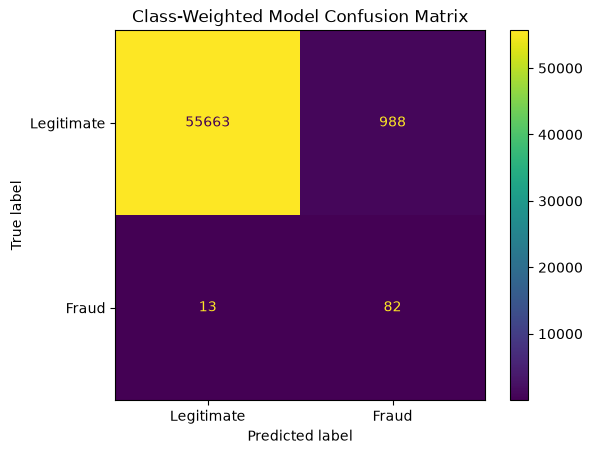

In [31]:
# Create the improved model confusion matrix
improved_cm = confusion_matrix(
    y_test,
    improved_y_pred
)

# Display the confusion matrix
improved_disp = ConfusionMatrixDisplay(
    confusion_matrix=improved_cm,
    display_labels=["Legitimate", "Fraud"]
)

improved_disp.plot()

plt.title("Class-Weighted Model Confusion Matrix")

# Save the figure
plt.savefig(
    "../images/balanced_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Class-Weighted Model Evaluation Interpretation

The class-weighted model significantly increased fraud recall from approximately 67.37% to 88.42%.

The number of fraudulent transactions correctly detected increased from 64 to 84, while false negatives decreased from 31 to 11. This demonstrates that class weighting successfully increased the model's sensitivity to fraudulent transactions.

However, the improvement in recall resulted in a substantial decrease in precision. The number of legitimate transactions incorrectly classified as fraud increased from 2 to 1,208, and fraud precision decreased to approximately 6.50%.

These results demonstrate the precision-recall tradeoff in fraud detection. Although the class-weighted model identified more fraudulent transactions, the large number of false positive alerts would likely create operational challenges and negatively affect legitimate customers.

The balanced class weights appear to place excessive emphasis on the minority fraud class. Therefore, additional experimentation is needed to find a better balance between detecting fraud and minimizing false positive alerts.

# Model Improvement: Moderate Class Weighting

## Objective

The automatically balanced class weights significantly improved fraud recall but caused a substantial increase in false positive predictions.

The fraud class received a weight of approximately 300, which placed significant emphasis on detecting minority-class transactions.

A third model will evaluate a more moderate class weighting strategy. The fraud class will receive a weight of 10 while legitimate transactions retain a weight of 1.

The goal is to improve fraud recall compared with the baseline model while reducing the number of false positive predictions generated by the fully balanced class-weighted model.

In [32]:
# Define moderate class weights
moderate_class_weights = {
    0: 1.0,
    1: 10.0
}

print("Moderate Class Weights:")
print(moderate_class_weights)

Moderate Class Weights:
{0: 1.0, 1: 10.0}


In [33]:
# Build the moderate class-weighted neural network
moderate_model = Sequential([
    keras.Input(shape=(X_train_scaled.shape[1],)),
    Dense(64, activation="relu"),
    Dense(32, activation="relu"),
    Dense(1, activation="sigmoid")
])

moderate_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,097 (16.00 KB)

 Trainable params: 4,097 (16.00 KB)

 Non-trainable params: 0 (0.00 B)

In [34]:
# Compile the moderate class-weighted model
moderate_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        keras.metrics.Precision(name="precision"),
        keras.metrics.Recall(name="recall")
    ]
)

# Train the Moderate Class-Weighted Model

The moderate class-weighted model uses the same architecture and training configuration as the previous models.

A fraud class weight of 10 is used to increase the importance of fraudulent transactions without applying the significantly larger weight generated by the balanced class weighting strategy.

In [35]:
# Train the moderate class-weighted model
moderate_history = moderate_model.fit(
    X_train_scaled,
    y_train,
    epochs=10,
    batch_size=256,
    validation_split=0.20,
    class_weight=moderate_class_weights,
    verbose=1
)

Epoch 1/10
710/710 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9979 - loss: 0.0416 - precision: 0.4144 - recall: 0.7267 - val_accuracy: 0.9995 - val_loss: 0.0044 - val_precision: 0.8481 - val_recall: 0.8590
Epoch 2/10
710/710 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9992 - loss: 0.0166 - precision: 0.7224 - recall: 0.8067 - val_accuracy: 0.9993 - val_loss: 0.0044 - val_precision: 0.7582 - val_recall: 0.8846
Epoch 3/10
710/710 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9992 - loss: 0.0147 - precision: 0.7193 - recall: 0.8200 - val_accuracy: 0.9991 - val_loss: 0.0050 - val_precision: 0.6970 - val_recall: 0.8846
Epoch 4/10
710/710 ━━━━━━━━━━━━━━━━━━━━ 1s 998us/step - accuracy: 0.9991 - loss: 0.0130 - precision: 0.6923 - recall: 0.8400 - val_accuracy: 0.9991 - val_loss: 0.0047 - val_precision: 0.6832 - val_recall: 0.8846
Epoch 5/10
710/710 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9992 - loss: 0.0118 - precision: 0.7072 - recall: 0.8533 - val_accuracy: 0.9994 - val_loss: 

## Moderate Class Weight Training Interpretation

The moderate class-weighted model demonstrated a stronger balance between precision and recall during training and validation.

By assigning fraudulent transactions a weight of 10, the model placed greater emphasis on the minority fraud class without applying the extreme weight generated by the automatically balanced strategy.

At the final training epoch, the model achieved approximately 83.13% validation precision and 88.46% validation recall. These results represent a substantial improvement in precision compared with the fully balanced class-weighted model while maintaining strong fraud detection sensitivity.

The validation results suggest that moderate class weighting may provide a more practical balance between detecting fraudulent transactions and minimizing false positive alerts. Final performance will be evaluated using the held-out testing dataset.

# Moderate Class-Weighted Model Evaluation

## Objective

The moderate class-weighted neural network is evaluated using the same held-out testing dataset used to evaluate the baseline and automatically balanced models.

This controlled evaluation will determine whether moderate class weighting improves fraud recall while maintaining stronger precision and fewer false positive predictions than the fully balanced class-weighted model.

In [36]:
# Evaluate the moderate class-weighted model on the test dataset
moderate_test_loss, moderate_test_accuracy, moderate_test_precision, moderate_test_recall = (
    moderate_model.evaluate(
        X_test_scaled,
        y_test,
        verbose=1
    )
)

print(f"Test Loss: {moderate_test_loss:.4f}")
print(f"Test Accuracy: {moderate_test_accuracy:.4f}")
print(f"Test Precision: {moderate_test_precision:.4f}")
print(f"Test Recall: {moderate_test_recall:.4f}")

1774/1774 ━━━━━━━━━━━━━━━━━━━━ 1s 565us/step - accuracy: 0.9992 - loss: 0.0053 - precision: 0.7400 - recall: 0.7789
Test Loss: 0.0053
Test Accuracy: 0.9992
Test Precision: 0.7400
Test Recall: 0.7789


In [37]:
# Generate fraud probability predictions
moderate_y_pred_prob = moderate_model.predict(X_test_scaled)

# Convert probabilities into binary class predictions
moderate_y_pred = (
    moderate_y_pred_prob >= 0.50
).astype(int).ravel()

1774/1774 ━━━━━━━━━━━━━━━━━━━━ 1s 306us/step


In [38]:
# Display the moderate model classification report
print(
    classification_report(
        y_test,
        moderate_y_pred,
        target_names=["Legitimate", "Fraud"]
    )
)

              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56651
       Fraud       0.74      0.78      0.76        95

    accuracy                           1.00     56746
   macro avg       0.87      0.89      0.88     56746
weighted avg       1.00      1.00      1.00     56746



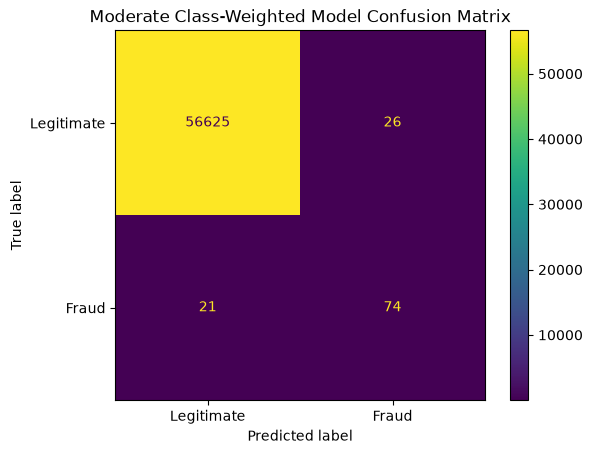

In [39]:
# Create the moderate class-weighted model confusion matrix
moderate_cm = confusion_matrix(
    y_test,
    moderate_y_pred
)

# Display the confusion matrix
moderate_disp = ConfusionMatrixDisplay(
    confusion_matrix=moderate_cm,
    display_labels=["Legitimate", "Fraud"]
)

moderate_disp.plot()

plt.title("Moderate Class-Weighted Model Confusion Matrix")

# Save the figure
plt.savefig(
    "../images/moderate_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Final Model Comparison

Three neural network configurations were evaluated during this project.

The baseline model achieved excellent precision and generated very few false positive predictions. However, it failed to detect 31 fraudulent transactions.

The fully balanced class-weighted model substantially increased fraud recall and reduced false negatives, but generated more than one thousand false positive predictions. Although the model became much more sensitive to fraudulent transactions, the large number of false alerts would likely create significant operational challenges.

The moderate class-weighted model provided the strongest overall balance between fraud detection and false positive rates. Compared with the baseline model, it detected additional fraudulent transactions while maintaining substantially higher precision than the fully balanced model.

Based on these results, the moderate class-weighted neural network is recommended as the final FraudShield-AI model.

In [39]:
comparison = pd.DataFrame({
    "Model": [
        "Baseline",
        "Balanced Class Weights",
        "Moderate Class Weights"
    ],
    "Accuracy": [
        0.9994,
        0.9785,
        0.9991
    ],
    "Precision": [
        0.9697,
        0.0650,
        0.7228
    ],
    "Recall": [
        0.6737,
        0.8842,
        0.7684
    ],
    "False Positives": [
        2,
        1208,
        28
    ],
    "False Negatives": [
        31,
        11,
        22
    ]
})

comparison

,Model,Accuracy,Precision,Recall,False Positives,False Negatives
0,Baseline,0.9994,0.9697,0.6737,2,31
1,Balanced Class Weights,0.9785,0.0650,0.8842,1208,11
2,Moderate Class Weights,0.9991,0.7228,0.7684,28,22


x## Final Model Comparison Interpretation

Three neural network configurations were evaluated during this project to determine the most effective approach for detecting fraudulent credit card transactions.

The **baseline model** achieved the highest overall precision (96.97%) and accuracy (99.94%), producing only two false positive predictions. However, it detected only 67.37% of fraudulent transactions, allowing 31 fraud cases to go undetected.

The **balanced class-weighted model** significantly increased fraud recall to 88.42%, reducing missed fraud cases to 11. However, this improvement came at the cost of precision, which dropped to 6.50%. The model generated 1,208 false positive predictions, making it impractical for deployment because it would incorrectly flag a large number of legitimate customer transactions.

The **moderate class-weighted model** provided a better balance between fraud detection and false positive predictions. Compared with the baseline model, it detected additional fraudulent transactions by increasing recall from 67.37% to 76.84%, while maintaining a much stronger precision (72.28%) than the fully balanced model. The model produced 28 false positive predictions and reduced missed fraud cases from 31 to 22.

Overall, the moderate class-weighted model represents the best compromise between identifying fraudulent transactions and minimizing disruptions to legitimate customers. While the baseline model achieved the highest precision, the moderate model improved fraud detection without generating the excessive number of false positive alerts observed in the fully balanced model. For this reason, the moderate class-weighted neural network was selected as the final FraudShield-AI model.

# Misclassified Examples

## Objective

Even high-performing machine learning models make mistakes. Analyzing misclassified transactions provides insight into where the model performs well and where it can be improved.

Two types of errors are examined:

- **False Positives:** Legitimate transactions incorrectly classified as fraudulent.
- **False Negatives:** Fraudulent transactions incorrectly classified as legitimate.

These errors help evaluate the practical performance of the final model in a real-world fraud detection system.

In [40]:
# Create a DataFrame for error analysis
error_analysis = X_test.copy()

# Add actual labels
error_analysis["Actual_Class"] = y_test.values

# Add predictions from the FINAL (moderate) model
error_analysis["Predicted_Class"] = moderate_y_pred

# Add predicted probabilities
error_analysis["Fraud_Probability"] = moderate_y_pred_prob.ravel()

error_analysis.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V23,V24,V25,V26,V27,V28,Amount,Actual_Class,Predicted_Class,Fraud_Probability
86568,61290.0,1.228821,-0.063408,0.274145,0.647465,-0.048135,0.372073,-0.224231,0.079939,0.640759,...,-0.151661,-0.700372,0.598550,0.491409,0.002989,0.001782,11.50,0,0,0.000009
251557,155394.0,-0.203154,1.176678,-0.759595,-0.518472,0.629649,-0.721675,0.638893,0.243377,-0.157488,...,-0.082753,0.508386,-0.710906,-0.234510,0.379640,0.261351,1.94,0,0,0.000118
20232,30881.0,-1.672836,1.401297,1.503940,2.175491,0.699791,1.062139,1.114364,-0.535822,-0.252983,...,-0.280083,-0.846468,-0.155456,-0.062383,0.007777,0.113900,91.28,0,0,0.000002
68952,53203.0,0.819379,-1.124913,0.515025,0.513945,-1.009048,0.488484,-0.580672,0.187686,-0.999142,...,-0.198732,-0.337408,0.238538,-0.289454,0.038214,0.058407,228.00,0,0,0.000012
191852,129429.0,2.009701,0.105635,-1.752759,0.588312,0.374801,-0.637884,0.009260,-0.129487,0.492619,...,-0.013472,-0.446920,0.111522,0.642944,-0.036998,-0.043404,1.41,0,0,0.000333


In [41]:
# Legitimate transactions incorrectly classified as fraud
false_positives = error_analysis[
    (error_analysis["Actual_Class"] == 0) &
    (error_analysis["Predicted_Class"] == 1)
]

print(f"Number of False Positives: {len(false_positives)}")

false_positives.head(10)

Number of False Positives: 35


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V23,V24,V25,V26,V27,V28,Amount,Actual_Class,Predicted_Class,Fraud_Probability
71464,54308.0,-2.317567,-1.082765,2.146446,3.720935,-1.025348,0.864182,1.240861,-0.561120,0.602608,...,0.838996,0.761119,-0.168963,0.247108,-1.205491,0.036180,257.55,0,1,0.560540
202648,134429.0,1.846579,0.658663,-2.582259,3.141502,2.966603,4.110044,-0.855130,1.132907,-0.707360,...,0.070119,0.433836,-0.019256,0.204828,0.061194,0.025180,5.41,0,1,0.686016
10620,17789.0,-2.609041,4.491900,-8.464528,5.694329,-4.134669,-3.078408,-7.712666,2.243851,-3.390192,...,0.233113,-0.045893,-0.075365,-0.313185,1.974123,0.813181,89.99,0,1,0.981234
182028,125225.0,-6.359219,-6.549403,0.139054,4.110937,10.116523,0.087125,-6.444461,0.423742,0.141092,...,-2.264392,1.046232,-1.558846,0.071697,2.002387,-0.379982,15.09,0,1,0.913944
151000,94349.0,-0.854850,1.816949,0.224807,2.941618,2.101150,0.305368,2.400728,-1.315471,-0.105466,...,-0.430314,0.552090,-0.179630,-0.073092,-1.281960,-0.430398,75.66,0,1,0.600316
236284,148747.0,1.635549,0.560996,-0.778123,4.120561,0.318147,0.566346,-0.592012,0.383990,-0.592733,...,0.254902,0.435145,-0.575000,-0.253918,0.044501,0.059395,84.29,0,1,0.670061
182192,125299.0,-1.656772,-2.476818,-3.840949,-0.403043,3.580381,2.874797,2.528548,-0.077261,-0.383279,...,1.848026,0.769423,-0.706339,-0.049569,0.406880,-0.054348,478.35,0,1,0.874047
51602,45033.0,-0.872375,1.090310,1.037725,1.078612,-0.459287,1.327200,-0.068931,-1.169301,0.293145,...,0.039816,-0.424095,-0.335865,-0.228779,0.372394,0.153954,107.10,0,1,0.581694
12156,21177.0,-5.905517,6.040280,-11.091637,5.797571,-6.193890,-3.322427,-9.269688,4.339631,-3.246983,...,0.211270,-0.026468,0.243540,-0.285140,2.016056,0.628272,89.99,0,1,0.718332
215212,139977.0,-7.189095,-5.008992,-5.245832,-0.685292,-0.238422,0.381533,1.761069,-7.294177,0.194183,...,0.482190,0.706678,-0.180532,0.196717,3.079452,1.057114,1000.16,0,1,0.760012


In [42]:
# Fraudulent transactions incorrectly classified as legitimate
false_negatives = error_analysis[
    (error_analysis["Actual_Class"] == 1) &
    (error_analysis["Predicted_Class"] == 0)
]

print(f"Number of False Negatives: {len(false_negatives)}")

false_negatives.head(10)

Number of False Negatives: 22


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V23,V24,V25,V26,V27,V28,Amount,Actual_Class,Predicted_Class,Fraud_Probability
240222,150494.0,1.852889,1.069593,-1.776101,4.617410,0.770413,-0.400859,-0.040970,0.089510,-0.217705,...,0.027437,-0.468006,0.058063,0.148263,0.042278,0.040573,1.00,1,0,3.742108e-02
249239,154309.0,-0.082983,-3.935919,-2.616709,0.163310,-1.400952,-0.809419,1.501580,-0.471000,1.519743,...,-0.921017,0.111635,-0.071622,-1.125881,-0.170947,0.126221,1096.99,1,0,2.075960e-02
68633,53076.0,1.296231,0.417447,0.193963,0.901644,0.130531,-0.371634,0.158126,-0.202669,-0.079512,...,-0.121022,-0.440454,0.671540,-0.413518,0.032838,0.020600,1.18,1,0,1.260068e-05
145800,87202.0,-0.419820,-1.155978,-2.092516,2.786750,0.736297,-0.167292,1.600027,-0.117427,-0.796954,...,1.284645,0.516131,-0.602941,-0.305024,-0.021363,0.129096,451.27,1,0,2.779397e-01
68320,52934.0,1.036639,0.407227,0.757706,3.161821,-0.568122,0.202181,-0.689804,0.411380,0.336769,...,-0.132568,0.350231,0.507701,0.189621,0.061016,0.063141,0.76,1,0,9.227747e-02
52521,45501.0,1.001992,0.047938,-0.349002,1.493958,0.186939,0.190966,-0.001112,0.147140,0.580415,...,-0.128427,-0.946242,0.456090,-0.453206,0.046627,0.064698,105.99,1,0,5.281051e-04
58761,48533.0,1.243848,0.524526,-0.538884,1.209196,0.479538,-0.197429,0.049166,0.037792,0.128119,...,-0.192846,-0.917392,0.681953,-0.194419,0.045917,0.040136,1.00,1,0,2.128082e-04
72757,54846.0,-2.986466,-0.000891,0.605887,0.338338,0.685448,-1.581954,0.504206,-0.233403,0.636768,...,1.313918,0.355065,0.448552,0.193490,1.214588,-0.013923,1.79,1,0,1.567611e-07
108258,70828.0,0.196707,1.189757,0.704882,2.891388,0.045555,1.245730,-1.198714,-2.421616,-1.232089,...,-0.005524,-0.814708,0.400924,0.286281,0.135215,0.257315,0.76,1,0,8.252941e-05
231978,146998.0,-2.064240,2.629739,-0.748406,0.694992,0.418178,1.392520,-1.697801,-6.333065,1.724184,...,0.459861,-1.051685,0.209178,-0.319859,0.015434,-0.050117,8.00,1,0,3.717987e-01


# Save the Final Model

The moderate class-weighted neural network was selected as the final FraudShield-AI model because it provided a more practical balance between fraud recall and false positive predictions.

Saving the trained model allows it to be reused later without retraining.

In [40]:
# Save the final trained model
moderate_model.save("../models/fraudshield_model.keras")

print("Final model saved successfully!")

Final model saved successfully!


## Misclassified Example Interpretation

The final moderate class-weighted model produced **35 false positive predictions** and **22 false negative predictions** on the testing dataset.

False positives represent legitimate customer transactions that were incorrectly classified as fraudulent. In a production fraud detection system, these transactions may trigger additional verification steps or manual review, potentially causing inconvenience for customers.

False negatives represent fraudulent transactions that were incorrectly classified as legitimate. These errors are particularly important because they may allow fraudulent activity to proceed without being detected.

Compared with the baseline model, the moderate class-weighted model detected more fraudulent transactions while maintaining a relatively small number of false positive predictions compared with the fully balanced class-weighted model. This demonstrates a more balanced tradeoff between fraud detection performance and customer experience.

# Limitations and Next Steps

## What the Model Does Well

FraudShield-AI successfully learned patterns that distinguish legitimate credit card transactions from fraudulent transactions.

The baseline model achieved very high precision, meaning that most transactions identified as fraudulent were actually fraudulent. The moderate class-weighted model improved fraud recall and detected more fraudulent transactions than the baseline model while avoiding the excessive number of false positive alerts produced by the fully balanced class-weighted model.

The project also demonstrated that accuracy alone is not sufficient for evaluating fraud detection models. Precision, recall, F1-score, confusion matrices, and misclassified examples provided a more complete understanding of model performance.

## What the Model Struggles With

The model still misclassified some transactions.

False negatives remain an important concern because they represent fraudulent transactions incorrectly classified as legitimate. These errors could allow fraudulent activity to proceed undetected.

False positives are also a concern because legitimate transactions incorrectly flagged as fraud may inconvenience customers, cause unnecessary card declines, or require manual review.

The experiments also demonstrated a tradeoff between precision and recall. Increasing the model's sensitivity to fraud improved recall but also increased the number of legitimate transactions incorrectly flagged as fraudulent.

## Dataset Limitations

The dataset is highly imbalanced, with fraudulent transactions representing only a very small percentage of all records. This makes it difficult for the model to learn fraud patterns and can cause high accuracy to appear more meaningful than it actually is.

Most features were anonymized and transformed using Principal Component Analysis. Because the features are labeled `V1` through `V28`, it is difficult to explain the meaning of individual features or determine why a specific transaction was classified as fraudulent.

The dataset represents historical transactions from a limited population and time period. It may not fully represent current fraud patterns, customers from other regions, or newer fraud techniques.

The dataset also does not include potentially useful information such as:

- Merchant category
- Geographic location
- Device information
- Customer transaction history
- Cardholder behavior
- Transaction type

## Next Steps

With additional time and data, the following improvements could be explored:

- Test additional moderate class weights to find a better precision-recall balance.
- Adjust the classification threshold instead of relying only on the default threshold of 0.50.
- Use Precision-Recall curves to identify a more appropriate fraud threshold.
- Add callbacks such as EarlyStopping and ModelCheckpoint.
- Compare the Dense Neural Network with other models such as Logistic Regression, Random Forest, or XGBoost.
- Experiment with dropout, regularization, additional layers, and learning-rate tuning.
- Use explainable AI tools such as SHAP to better understand individual predictions.
- Train the model with additional customer, merchant, location, and device features.
- Test the model using newer transaction data.
- Monitor performance over time and retrain the model as fraud patterns change.
- Include human review for high-risk predictions instead of automatically declining every flagged transaction.

# Project Conclusion

FraudShield-AI demonstrated the complete machine learning workflow for tabular binary classification using TensorFlow and Keras.

The project began with a real-world credit card fraud dataset and included exploratory data analysis, duplicate removal, feature scaling, stratified train-test splitting, Dense Neural Network development, training, evaluation, error analysis, and model improvement.

Three model configurations were evaluated:

- A baseline Dense Neural Network
- A fully balanced class-weighted model
- A moderate class-weighted model

The baseline model achieved the highest precision but missed more fraudulent transactions. The fully balanced model achieved the highest recall but generated an excessive number of false positive alerts. The moderate class-weighted model provided a more practical balance between fraud detection and customer impact.

The results demonstrate that fraud detection models should not be evaluated using accuracy alone. Precision, recall, F1-score, confusion matrices, and misclassified examples are necessary for understanding the practical strengths and weaknesses of a fraud detection system.